<a href="https://colab.research.google.com/github/sap-tarshi-ghosh/Image-Processing-Tutorial/blob/main/code/03_Neighborhood_Based_Image_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the image

In [2]:
from PIL import Image

image = Image.open('/kaggle/input/testing-image/low-contrast-04.jpg').convert('L')

width, height = image.size

pixels = list(image.getdata())

#converting the image into a 2d list
img = []
for y in range(height):
  row = []
  for x in range(width):
    row.append(pixels[y * width + x])
  img.append(row)



In [18]:
store_min = min(min(row) for row in img)
store_max = max(max(row) for row in img)

print(f'{store_min}, {store_max}')

0, 198


# Applying mean filter

In [3]:
mean_img = []

for y in range(height):
  row = []
  for x in range(width):
    row.append(img[y][x])
  mean_img.append(row)

In [4]:
'''for y in range(height):
  for x in range(width):
    total = 0

    temp = [-1, 0, 1]
    for dy in temp:
      for dx in temp:
        total += img[y + dy][x + dx]

    mean_img[y][x] = int(total/9)'''

'for y in range(height):\n  for x in range(width):\n    total = 0\n\n    temp = [-1, 0, 1]\n    for dy in temp:\n      for dx in temp:\n        total += img[y + dy][x + dx]\n\n    mean_img[y][x] = int(total/9)'

I have comment out the previous code because in this code i recived "**out of index error**", and the reason for the error was the code was trying to calculate mean for the **edge pixels** as well. The next block cantains the correct version of the c

In [5]:
for y in range(1, height -1):
  for x in range(1, width - 1):
    total = 0

    temp = [-1, 0, 1]
    for dy in temp:
      for dx in temp:
        total += img[y + dy][x + dx]

    mean_img[y][x] = int(total/9)

Visulising the picture

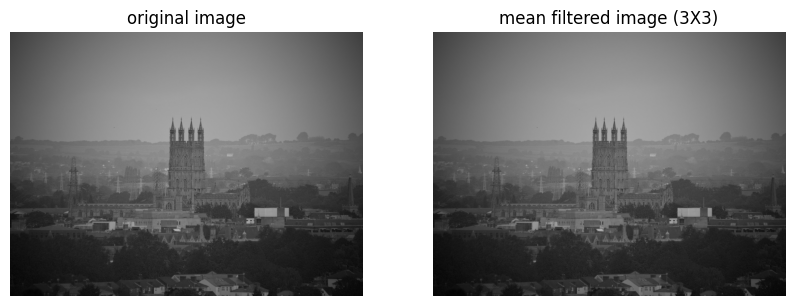

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.axis('off')
plt.title('original image')

plt.subplot(1, 2, 2)
plt.imshow(mean_img, cmap='gray', vmin=0, vmax=255)
plt.title('mean filtered image (3X3)')
plt.axis('off')

plt.show()

# Median filter

In [7]:
median_img = []

for y in range( height):
  row = []
  for x in range(width):
    row.append(img[y][x])
  median_img.append(row)

In [8]:
for y in range(2, height -2):
  for x in range(2, width -2):

    window = []
    sq3_3 = [-2, -1, 0, 1, 2]
    for dy in sq3_3:
      for dx in sq3_3:
        window.append(img[y + dy][x + dx])


    window.sort()

    median_img[y][x] = window[12] #because index 12 means 13th element and the middle in case of 5X5 matrix

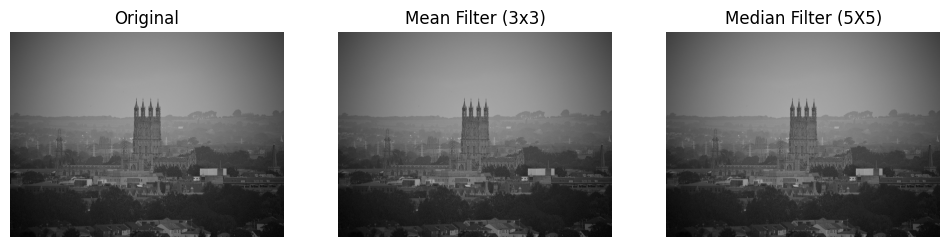

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mean_img, cmap='gray', vmin=0, vmax=255)
plt.title("Mean Filter (3x3)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(median_img, cmap='gray', vmin=0, vmax=255)
plt.title("Median Filter (5X5)")
plt.axis('off')

plt.show()


# Neighbourhood based edge detection

In [32]:
edge_img = []

for y in range(height):
    rows = []
    for x in range(width):
        rows.append(img[y][x])
    edge_img.append(rows)
    

Here the horizontal pixel difference is taken

In [33]:
for y in range(height):
    for x in range(1, width):
        diff = edge_img[y][x - 1] - edge_img[y][x]
        if diff < 0:
            diff = -diff    #taking the absolute value
        edge_img[y][x] = diff

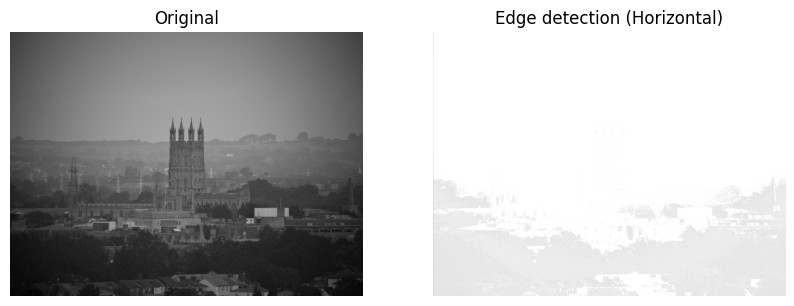

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(edge_img, cmap='gray', vmin=0, vmax=255)
plt.title("Edge detection (Horizontal)")
plt.axis('off')

plt.show()
